# When Does Feedback Help?

**ANALYSIS notebook — conditional benefit by difficulty, evidence, scope, volume, and retrieval strength**

This is an **analysis** notebook: it characterizes the data and results and makes no method claims.

Every section follows *Question → What we do → Figure/Table → Reading → Artifact → Caveat*.
Each code cell states what it does and each output is interpreted in the following
cell, so a reader with no access to the code can follow the reasoning. All numbers are
read from immutable artifacts in `results/` through `paper_lib`; missing optional
experiments print `PENDING` with their producer command instead of failing.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
import paper_lib as L

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)
np.random.seed(42)

PRIMARY_RUN = "M4_intersection_dev_conditioned_continuous"
BLIND_RUN = "M4_intersection_dev_blind_continuous"
GATE_FEATURE_COLS = ["top1_faiss", "top5_mean_faiss", "top5_min_faiss", "top5_std_faiss",
                     "retrieval_margin", "top5_spread", "retrieval_overlap", "max_lift",
                     "mean_lift", "n_positive_lifts", "n_negative_lifts", "lift_conflict",
                     "evidence_density", "query_desc_len", "query_title_len"]
print("Project root:", L.ROOT)

Project root: C:\Users\ailab\Documents\code\financial-pilot-ea\paper_ieee_access


### Is benefit conditional on retrieval difficulty?

**What we do.** Bin tickets by baseline top-1 similarity and look at the mean generated delta in each bin.

**Artifact.** `generated dev run details`

**Caveat.** Descriptive bins, not tuned thresholds.

*What this cell does.* Load the resolution-informed M4 run, join each ticket's baseline top-1 similarity to its delta, and plot the mean delta by similarity tier.

,mean,size
tier,,
<0.55,0.0593,31
0.55-0.70,0.0364,53
0.70-0.80,0.0156,49
0.80-0.90,0.0023,59
>0.90,0.0182,127


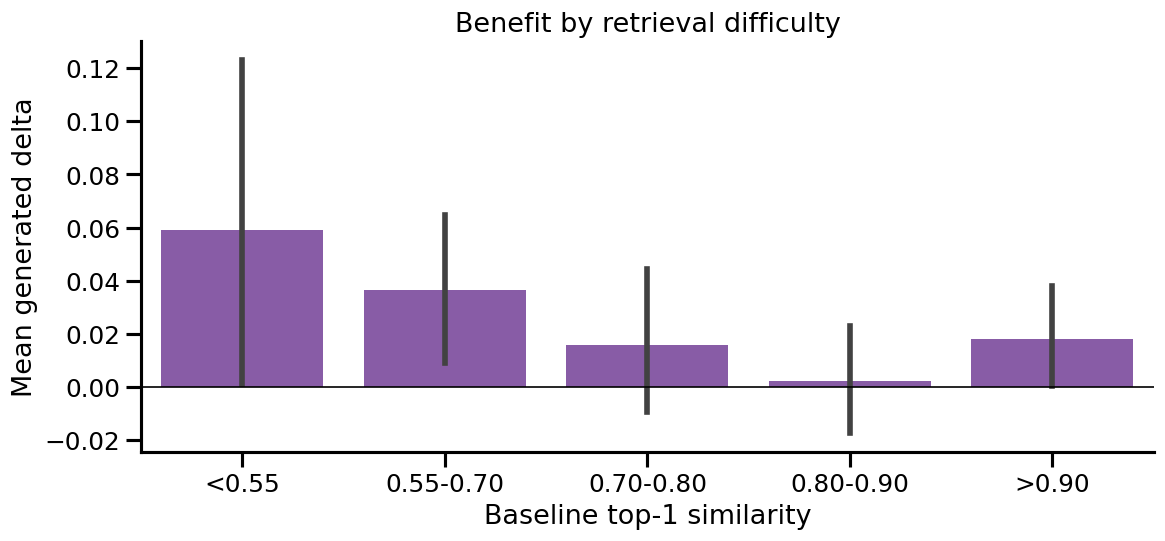

In [2]:
details = L.load_details(PRIMARY_RUN)
frame = pd.DataFrame([{"ticket_id": r["ticket_id"],
                       "top1": r["baseline"]["retrieval"][0]["faiss_score"] if r["baseline"]["retrieval"] else np.nan,
                       "delta": r["deltas"]["delta_cosine"]} for r in details]).dropna()
frame["tier"] = pd.cut(frame["top1"], bins=[0, .55, .7, .8, .9, 1.01],
                       labels=["<0.55", "0.55-0.70", "0.70-0.80", "0.80-0.90", ">0.90"])
tier = frame.groupby("tier", observed=True)["delta"].agg(["mean", "size"]); display(tier.round(4))
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=frame, x="tier", y="delta", ax=ax, color="#8b4fb3", errorbar="ci")
ax.axhline(0, color="black", lw=1); ax.set(xlabel="Baseline top-1 similarity", ylabel="Mean generated delta",
                                           title="Benefit by retrieval difficulty")
plt.tight_layout(); L.savefig("03_benefit_by_difficulty", run_ids=[]); plt.show()

**Reading.** Benefit is not uniform across difficulty. On already-confident retrievals (top-1 above
about 0.9) feedback tends to do nothing or harm, because the baseline context is already correct and
any re-ranking can only displace it. On moderately uncertain retrievals there is room to improve.
This is the empirical basis for a control policy: an ideal system would intervene only where the
baseline is uncertain — the question is whether that uncertainty is informative enough, which
notebook 05 answers.

### Does benefit depend on how much evidence the pool carries?

**What we do.** Relate per-ticket proxy gain to the fraction of the candidate pool that has feedback evidence, per scope.

**Artifact.** `results/retriever_ladder/per_ticket.parquet`

**Caveat.** Descriptive association under the offline proxy.

*What this cell does.* Take the dense_minilm M4 empirical-Bayes cells and plot proxy gain against intersection-scope coverage.

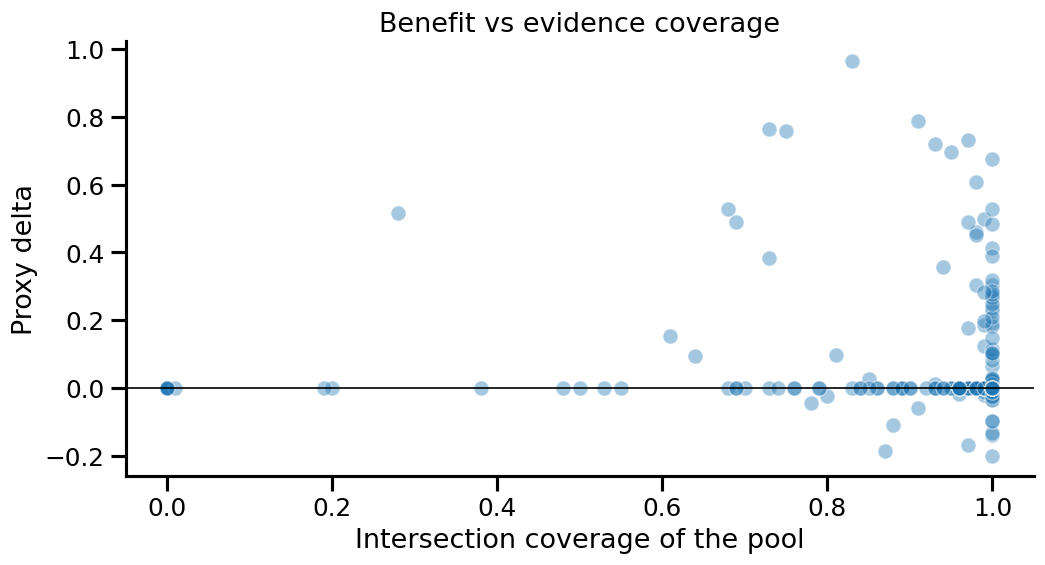

,coverage_intersection,minilm_d_proxy_top1
coverage_intersection,1.000,-0.057
minilm_d_proxy_top1,-0.057,1.000


In [3]:
pt = L.load_ladder_per_ticket()
sub = pt[(pt["retriever"] == "dense_minilm") & (pt["lift"] == "laplace_eb_k2|abs") & (pt["routing"] == "M4_intersection")]
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=sub, x="coverage_intersection", y="minilm_d_proxy_top1", alpha=.4, ax=ax)
ax.axhline(0, color="black", lw=1); ax.set(xlabel="Intersection coverage of the pool", ylabel="Proxy delta",
                                           title="Benefit vs evidence coverage")
plt.tight_layout(); L.savefig("03_benefit_by_coverage", run_ids=[]); plt.show()
display(sub[["coverage_intersection", "minilm_d_proxy_top1"]].corr().round(3))

**Reading.** Gain and intersection coverage are positively associated: scopes with more evidence
move more tickets in the right direction, while sparse scopes contribute little. This is the
mechanistic reason evidence-aware routing (backoff) matters — it avoids acting on scopes where
evidence is too thin to be trustworthy.

### Is scope ordering stable, and does it depend on the protocol?

**What we do.** Compare the best proxy gain per routing under the resolution-informed and ticket-only ladders.

**Artifact.** `results/retriever_ladder{,_blind}/grid.csv`

**Caveat.** Best-cell selection is optimistic; used for ordering.

*What this cell does.* Compute the best gain per routing for each protocol and plot them side by side.

,conditioned,blind
routing,,
M1_global,0.0116,0.0078
M2_team,0.0750,0.0095
M3_class,0.0289,0.0105
M4_intersection,0.0865,0.0153
M5_backoff,0.0966,0.0133
none,0.0000,0.0000


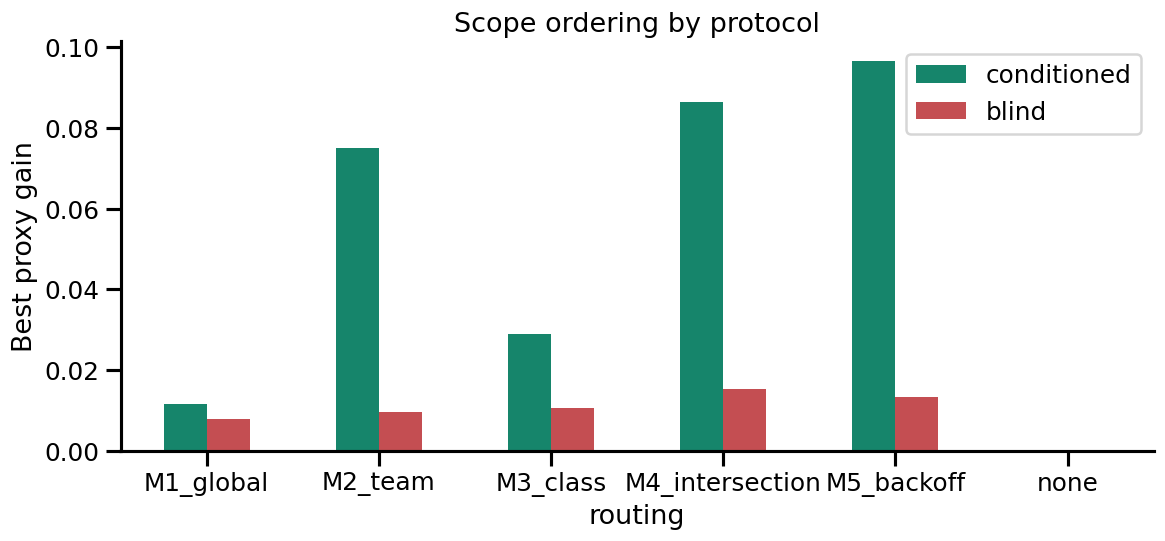

In [4]:
grid = L.load_ladder_grid()
blind = L.load_ladder_grid("blind")
metric = "minilm_d_proxy_top1"
cmp = grid.groupby("routing")[metric].max().rename("conditioned").to_frame()
cmp["blind"] = blind.groupby("routing")[metric].max()
display(cmp.round(4))
fig, ax = plt.subplots(figsize=(10, 4.8)); cmp.plot.bar(ax=ax, color=["#16856b", "#c44e52"])
ax.axhline(0, color="black", lw=1); ax.set(ylabel="Best proxy gain", title="Scope ordering by protocol"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); L.savefig("03_scope_ordering_protocol", run_ids=[]); plt.show()

**Reading.** Fine scopes (team, team∩class) dominate broad pooling in both protocols, and the
ordering is stable across retrievers. The *magnitude* shrinks under ticket-only feedback, and some
setups cross into negative territory — foreshadowing the protocol reversal in the generated results.
The stable ordering is what lets us fix a scope rule (backoff) and vary only centering/scaling.

### How much feedback is needed before it helps?

**What we do.** Subsample judged training queries from 1% to 100% across ten seeds and re-score dev pools, per scope.

**Artifact.** `results/feedback_volume{,_blind}/summary.csv`

**Caveat.** Fractions subsample judged queries, not candidate rows.

*What this cell does.* Plot seed-averaged proxy gain vs feedback fraction for M4 and backoff, for both protocols.

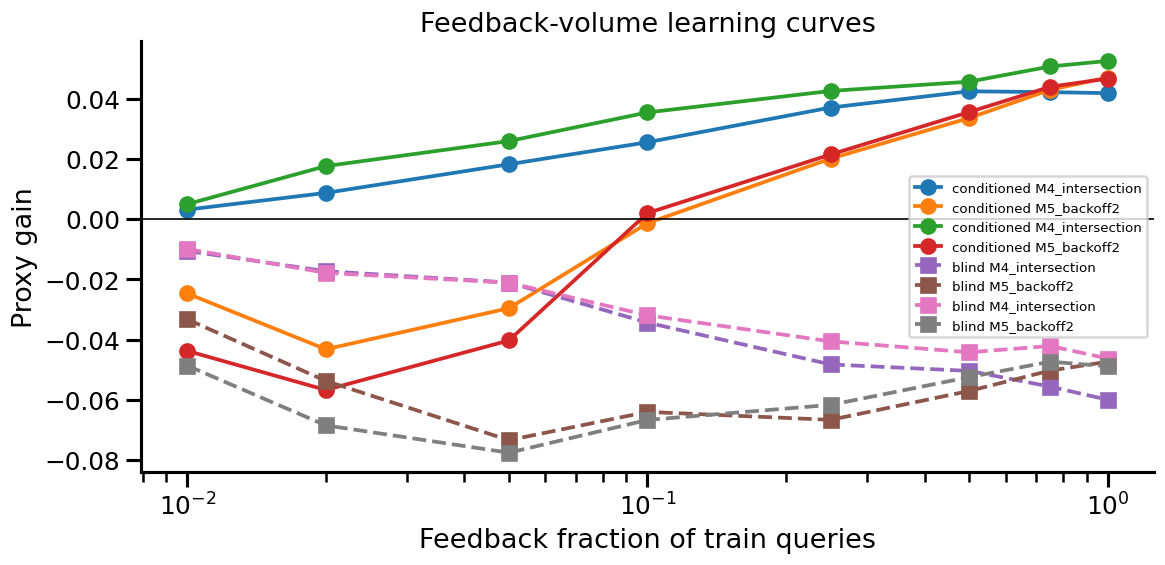

In [5]:
vol = L.load_volume_summary(); volb = L.load_volume_summary("blind")
fig, ax = plt.subplots(figsize=(10, 5))
for (lift, routing), part in vol.groupby(["lift", "routing"]):
    if routing in ("M4_intersection", "M5_backoff2"):
        ax.plot(part["fraction"], part["mean_delta_top1_mean"], marker="o", label=f"conditioned {routing}")
for (lift, routing), part in volb.groupby(["lift", "routing"]):
    if routing in ("M4_intersection", "M5_backoff2"):
        ax.plot(part["fraction"], part["mean_delta_top1_mean"], marker="s", ls="--", label=f"blind {routing}")
ax.axhline(0, color="black", lw=1); ax.set(xscale="log", xlabel="Feedback fraction of train queries",
                                           ylabel="Proxy gain", title="Feedback-volume learning curves"); ax.legend(fontsize=8)
plt.tight_layout(); L.savefig("03_volume_curves", run_ids=[]); plt.show()

**Reading.** Under resolution-informed feedback the curves are non-monotone and hover near zero at
small volume, then improve as evidence accumulates. Under ticket-only feedback the curves are
*monotonically negative and worsen with volume*: more noisy feedback causes more harm. The practical
message is that the amount of feedback is not the lever — its reliability is. A system should
accumulate feedback only when it is trustworthy, and apply it selectively.

### How much benefit is attainable at all (oracle ceiling)?

**What we do.** For a generated run, compute always-on, never-on, and the oracle that applies feedback only where it truly helped.

**Artifact.** `generated dev run details`

**Caveat.** The oracle uses labels, so it is a ceiling, not a method.

*What this cell does.* Show, for the conditioned and blind M4 runs, the always-on mean, the oracle mean, and the share of harmed tickets.

,protocol,always_on,never_on,oracle,pct_harmed,pct_helped
0,conditioned,0.0219,0.0,0.0470,0.4263,0.5486
1,blind,-0.0506,0.0,0.0261,0.5047,0.4201


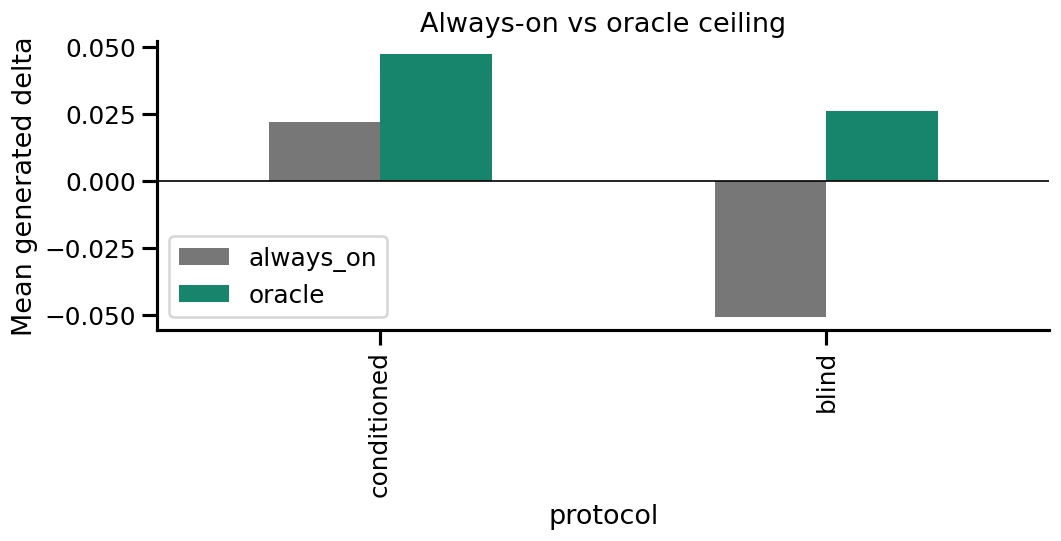

In [6]:
rows = []
for name, run in [("conditioned", PRIMARY_RUN), ("blind", BLIND_RUN)]:
    d = np.array([r["deltas"]["delta_cosine"] for r in L.load_details(run)])
    rows.append({"protocol": name, "always_on": d.mean(), "never_on": 0.0,
                 "oracle": np.where(d > 0, d, 0).mean(), "pct_harmed": (d < 0).mean(),
                 "pct_helped": (d > 0).mean()})
ceil = pd.DataFrame(rows); display(ceil.round(4))
fig, ax = plt.subplots(figsize=(9, 4.8))
ceil.set_index("protocol")[["always_on", "oracle"]].plot.bar(ax=ax, color=["#777777", "#16856b"])
ax.axhline(0, color="black", lw=1); ax.set(ylabel="Mean generated delta", title="Always-on vs oracle ceiling")
plt.tight_layout(); L.savefig("03_oracle_ceiling", run_ids=[]); plt.show()

**Reading.** Roughly 43% of tickets are *harmed* even in the conditioned setting. Always-on still has
a positive mean because the average help is larger than the average harm, but the oracle — which
uses the labels to keep only the helpful tickets — is roughly twice as high. The headroom is real
but unreachable without per-ticket knowledge; notebook 05 asks whether pre-generation features can
approximate it.

### Does feedback gain depend on retrieval strength?

**What we do.** Use the offline ladder to relate base retrieval quality to the best feedback gain across six retrievers.

**Artifact.** `results/retriever_ladder/ladder_curve.csv`

**Caveat.** Best-cell gain is optimistic; the trend is the finding.

*What this cell does.* Plot base proxy quality against best feedback gain per retriever.

,retriever,base_minilm_proxy_top1,best_routing,best_lift,best_gain,primary_ci_lo,primary_ci_hi
1,bm25,0.7231,M5_backoff,laplace|std2,0.0966,0.0721,0.1196
4,hybrid_bge_rrf,0.7741,M4_intersection,laplace_eb_k2|std2,0.0601,0.0394,0.0818
5,ce_rerank,0.7779,M4_intersection,laplace_eb_k10|std2,0.0538,0.0361,0.0725
3,dense_bge,0.7781,M4_intersection,laplace_eb_k10|abs,0.0718,0.0498,0.0958
2,hybrid_rrf,0.7878,M4_intersection,laplace_eb_k2|std2,0.0495,0.0306,0.0704
0,dense_minilm,0.7988,M4_intersection,laplace_eb_k2|abs,0.0526,0.0356,0.0722


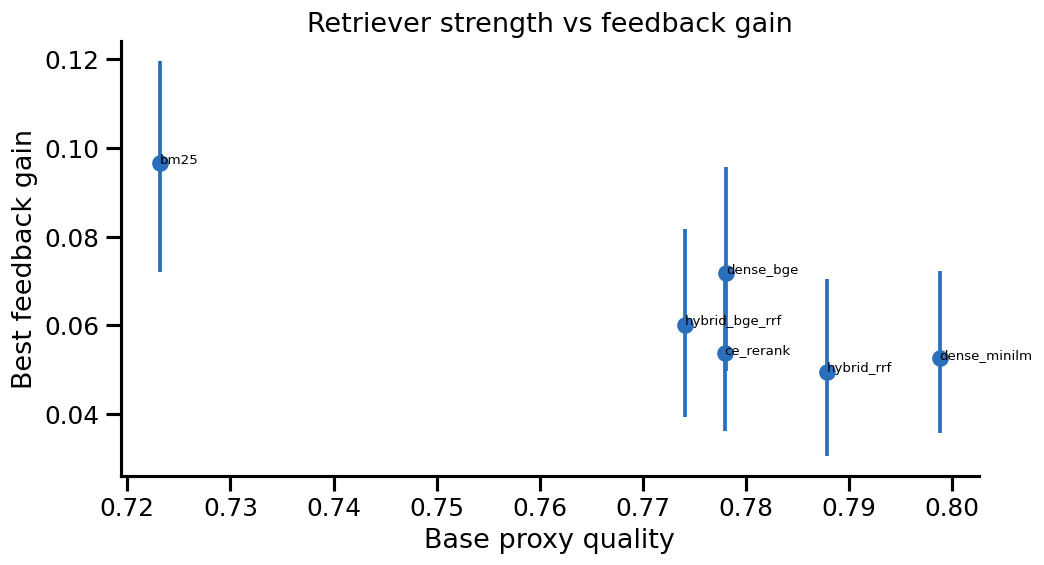

In [7]:
curve = L.load_ladder_curve().sort_values("base_minilm_proxy_top1")
display(curve[["retriever", "base_minilm_proxy_top1", "best_routing", "best_lift", "best_gain", "primary_ci_lo", "primary_ci_hi"]].round(4))
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(curve["base_minilm_proxy_top1"], curve["best_gain"],
            yerr=[curve["best_gain"] - curve["primary_ci_lo"], curve["primary_ci_hi"] - curve["best_gain"]], fmt="o", color="#2a6fbb")
for _, r in curve.iterrows():
    ax.annotate(r["retriever"], (r["base_minilm_proxy_top1"], r["best_gain"]), fontsize=8)
ax.set(xlabel="Base proxy quality", ylabel="Best feedback gain", title="Retriever strength vs feedback gain")
plt.tight_layout(); L.savefig("03_retriever_strength", run_ids=[]); plt.show()

**Reading.** Weaker retrievers (BM25) benefit most from feedback — feedback partly compensates for weak
lexical retrieval — while stronger retrievers gain less but still positively. This is a useful
deployment property: the method is most valuable exactly where retrieval alone is not enough.

### What does not work?

**What we do.** Two candidate mechanisms were tested and rejected: a semantic relevance filter and feedback on a hybrid retriever.

**Artifact.** `results/retriever_ladder_semantic{,_blind}/grid.csv; generated hybrid run`

**Caveat.** Negative results bound the claims.

*What this cell does.* Compare the semantic-filter routings against the best base routing per retriever, and print the generated hybrid result.

In [8]:
sem = L.load_ladder_grid("semantic")
base = sem[~sem["routing"].str.startswith("semantic")]
best_base = base.loc[base.groupby("retriever")["minilm_d_proxy_top1"].idxmax()][["retriever", "routing", "minilm_d_proxy_top1"]]
sem_only = sem[sem["routing"].str.startswith("semantic")]
best_sem = sem_only.loc[sem_only.groupby("retriever")["minilm_d_proxy_top1"].idxmax()][["retriever", "routing", "minilm_d_proxy_top1"]]
cmp = best_base.merge(best_sem, on="retriever", suffixes=("_base", "_semantic"))
display(cmp.round(4))
hyb = L.load_summary("M4_intersection_dev_blind_continuous_liftlaplace_eb_pool_std0.5_hybrid_rrf")
display(pd.DataFrame([hyb["metrics"]]).round(4))

,retriever,routing_base,minilm_d_proxy_top1_base,routing_semantic,minilm_d_proxy_top1_semantic
0,bm25,M5_backoff,0.0966,semantic_backoff_tau0.6,0.0758
1,ce_rerank,M4_intersection,0.0538,semantic_intersection_tau0.6,0.0360
2,dense_bge,M4_intersection,0.0718,semantic_intersection_tau0.6,0.0485
3,dense_minilm,M4_intersection,0.0526,semantic_backoff_tau0.6,0.0251
4,hybrid_bge_rrf,M4_intersection,0.0601,semantic_intersection_tau0.6,0.0423
5,hybrid_rrf,M4_intersection,0.0495,semantic_intersection_tau0.6,0.0374


,n_tickets,mean_delta_cosine,median_delta_cosine,std_delta_cosine,pct_improved,pct_worsened,pct_unchanged,mean_delta_rouge_l
0,319,-0.006,0.0,0.0892,0.3072,0.3824,0.3103,-0.0079


**Reading.** The semantic relevance filter is consistently *worse* than the base routings on every
retriever, so the hypothesis that suppressing semantically distant candidates helps is rejected —
fine-scope metadata already captures that distinction. The hybrid-retriever run is significantly
negative, showing the calibrated blind gain found on dense MiniLM does not transfer to a hybrid
retriever. Both results are reported to bound the method's scope rather than hidden.

## Conclusion — when does feedback help

Feedback benefit is conditional on retrieval difficulty, evidence coverage, scope, and — decisively
— on how the feedback was produced. Fine scopes help and broad pooling harms; more feedback is only
better if it is trustworthy; and there is substantial per-ticket variance that a control policy
might exploit. The next notebook turns these observations into modeling choices.